Name: Navpreet Kloy

Monday Lab Partner: Oscar Ramos

Wednesday Lab Partner: Oscar Ramos

Consumer Shopping Trends Analysis:
https://www.kaggle.com/datasets/minahilfatima12328/consumer-shopping-trends-analysis

In [ ]:
# Import necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# load dataset("Consumer_Shopping_Trends.csv")
df = pd.read_csv("Consumer_Shopping_Trends.csv")
df

,age,monthly_income,daily_internet_hours,smartphone_usage_years,social_media_hours,online_payment_trust_score,tech_savvy_score,monthly_online_orders,monthly_store_visits,avg_online_spend,...,free_return_importance,product_availability_online,impulse_buying_score,need_touch_feel_score,brand_loyalty_score,environmental_awareness,time_pressure_level,gender,city_tier,shopping_preference
0,56,221111,6.5,12,0.7,1,6,16,16,28551,...,7,7,1,3,6,5,2,Other,Tier 3,Store
1,69,96029,8.2,13,2.7,6,9,14,1,124056,...,3,4,9,6,8,1,7,Male,Tier 3,Hybrid
2,46,19055,6.4,4,2.1,10,8,2,0,81939,...,4,10,1,1,3,3,3,Female,Tier 3,Store
3,32,53170,6.4,11,0.7,2,10,20,3,35901,...,10,2,4,8,2,6,6,Female,Tier 1,Store
4,60,244016,6.0,5,0.7,2,5,18,16,131971,...,2,5,8,9,7,1,6,Male,Tier 3,Store
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11784,67,151087,10.4,4,2.2,2,5,42,4,70860,...,9,9,7,2,8,7,6,Other,Tier 1,Store
11785,60,243273,6.1,10,3.0,3,2,20,14,90420,...,4,7,10,8,2,1,10,Female,Tier 2,Store
11786,53,154729,4.6,13,1.8,8,2,11,15,18700,...,5,9,1,3,4,6,1,Female,Tier 2,Store
11787,65,66116,6.2,3,1.0,1,1,31,0,61475,...,1,7,10,10,2,2,9,Other,Tier 1,Store


In [ ]:
# view class distrubtion of shopping preference
print(df['shopping_preference'].value_counts())

shopping_preference
Store     10244
Online     1176
Hybrid      369
Name: count, dtype: int64


In [ ]:
#convert categorical columns into numbers (same style, simple)
le_gender=LabelEncoder()
df['gender']=le_gender.fit_transform(df['gender'])

le_city=LabelEncoder()
df['city_tier']=le_gender.fit_transform(df['city_tier'])

le_target=LabelEncoder()
df['shopping_preference']=le_gender.fit_transform(df['shopping_preference'])
df

,age,monthly_income,daily_internet_hours,smartphone_usage_years,social_media_hours,online_payment_trust_score,tech_savvy_score,monthly_online_orders,monthly_store_visits,avg_online_spend,...,free_return_importance,product_availability_online,impulse_buying_score,need_touch_feel_score,brand_loyalty_score,environmental_awareness,time_pressure_level,gender,city_tier,shopping_preference
0,56,221111,6.5,12,0.7,1,6,16,16,28551,...,7,7,1,3,6,5,2,2,2,2
1,69,96029,8.2,13,2.7,6,9,14,1,124056,...,3,4,9,6,8,1,7,1,2,0
2,46,19055,6.4,4,2.1,10,8,2,0,81939,...,4,10,1,1,3,3,3,0,2,2
3,32,53170,6.4,11,0.7,2,10,20,3,35901,...,10,2,4,8,2,6,6,0,0,2
4,60,244016,6.0,5,0.7,2,5,18,16,131971,...,2,5,8,9,7,1,6,1,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11784,67,151087,10.4,4,2.2,2,5,42,4,70860,...,9,9,7,2,8,7,6,2,0,2
11785,60,243273,6.1,10,3.0,3,2,20,14,90420,...,4,7,10,8,2,1,10,0,1,2
11786,53,154729,4.6,13,1.8,8,2,11,15,18700,...,5,9,1,3,4,6,1,0,1,2
11787,65,66116,6.2,3,1.0,1,1,31,0,61475,...,1,7,10,10,2,2,9,2,0,2


In [ ]:
#renaming column names to make it easier to understand
df = df.rename(columns={
    'monthly_online_orders': 'online_orders',
    'monthly_store_visits': 'store_visits',
    'avg_online_spend': 'online_spend',
    'avg_store_spend': 'store_spend',
    'daily_internet_hours': 'internet_hours',
    'social_media_hours': 'social_hours'})

In [ ]:
#Features and Target
X=df.drop('shopping_preference', axis=1)
y=df['shopping_preference']

In [ ]:
#split data into training (70%) and testing (30%) sets
X_train, X_test, y_train, y_test=train_test_split(
    X,y, test_size=0.3, random_state=42
)

In [ ]:
#create an SVM classifier with RBF kernel
svm_classifier=SVC(kernel='rbf', gamma='scale', C=1.0, class_weight='balanced') ##

In [ ]:
#Train the model
print("Training the SVM model...")
svm_classifier.fit(X_train, y_train)
print("Training complete!")

#Make predictions on test data
y_pred=svm_classifier.predict(X_test)

Training the SVM model...
Training complete!


In [ ]:
#Calculate accuracy
accuracy=accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy * 100:.2f}%")

#Create a confusion matrix
cm=confusion_matrix(y_test, y_pred)

# Classification Report for model
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Hybrid', 'In-store', 'Online']))


Accuracy: 82.70%

Classification Report:
              precision    recall  f1-score   support

      Hybrid       0.10      0.58      0.17       102
    In-store       0.73      0.71      0.72       346
      Online       1.00      0.85      0.92      3089

    accuracy                           0.83      3537
   macro avg       0.61      0.71      0.60      3537
weighted avg       0.95      0.83      0.88      3537




Total test samples: 3537
Correctly classified: 2925
Incorrectly classified: 612

EXPLANATION:
This program uses a Support Vector Machine with an RBF kernel to predict
customer shopping preferences based on behavioral and demographic data.
The model learns patterns such as online activity, spending habits, and
customer characteristics to classify whether a customer prefers online,
in-store, or hybrid shopping. The confusion matrix shows how well the
model performs and where it makes mistakes.


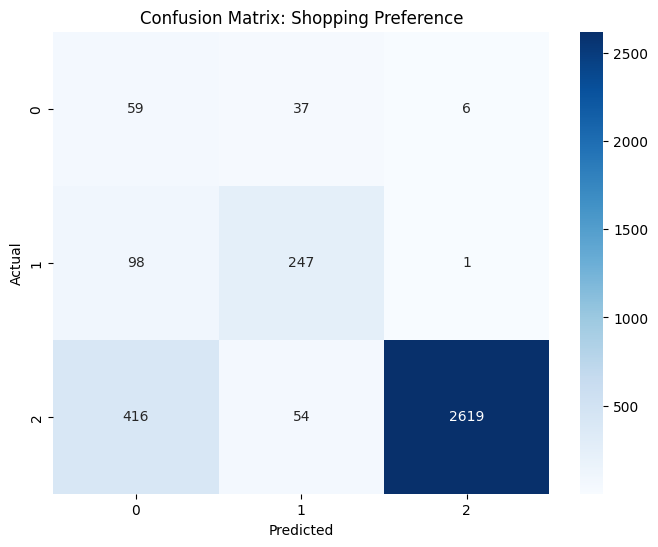

In [ ]:
#Visualize the confusion matrix
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: Shopping Preference')

#Print some statistics
print(f"\nTotal test samples: {len(y_test)}")
print(f"Correctly classified: {(y_test==y_pred).sum()}")
print(f"Incorrectly classified: {(y_test != y_pred).sum()}")

print("\n"+"="*70)
print("EXPLANATION:")
print("="*70)
print("This program uses a Support Vector Machine with an RBF kernel to predict")
print("customer shopping preferences based on behavioral and demographic data.")
print("The model learns patterns such as online activity, spending habits, and")
print("customer characteristics to classify whether a customer prefers online,")
print("in-store, or hybrid shopping. The confusion matrix shows how well the")
print("model performs and where it makes mistakes.")
print("="*70)

SUMMARY:
This program applies a Support Vector Machine (SVM) with an RBF kernel to classify customer shopping preferences using the Consumer Shopping Trends dataset. First, the data is loaded and categorical variables such as gender, city tier, and shopping preference are converted into numerical values using LabelEncoder. Some column names are simplified for readability, and the dataset is then split into training and testing sets. The SVM model is trained on the training data and used to make predictions on the test data. The model's performance is evaluated using accuracy and a confusion matrix, which shows how well the model correctly classifies customer preferences.